# Best 70-string geometries

This notebook plots the learned top-70 string subset from the best checkpoint for each `class x target` geometry-selection run.

It uses only Python standard-library CSV parsing and inline SVG, so it does not require `pandas` or `matplotlib`.

In [1]:
from pathlib import Path
import csv
import html
from IPython.display import SVG, display

BASE_DIR = Path('/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/full_geometry_emax1e6/geometry_selection/first_category')
RESULTS_DIR = BASE_DIR / 'results'
COORDS_CSV = Path('/project/def-nahee/kbas/Graphnet-Applications/Metadata/GeometryFiles/string_coordinates_340_string_mc.csv')

EXPERIMENT = 'exp003'
TRAIN_DIR = 'train_and_val'
CLASSES = ['class0', 'class1']
TARGETS = ['zenith', 'azimuth', 'energy']

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def read_csv_rows(path):
    with open(path, newline='') as f:
        return list(csv.DictReader(f))


def run_dir(class_name, target):
    return BASE_DIR / class_name / EXPERIMENT / TRAIN_DIR / target


def parse_bool(value):
    return str(value).strip().lower() in {'true', '1', 'yes'}


coords = []
for row in read_csv_rows(COORDS_CSV):
    coords.append({
        'string_id': int(row['string']),
        'x': float(row['x']),
        'y': float(row['y']),
    })

coord_by_string = {row['string_id']: row for row in coords}
xs = [row['x'] for row in coords]
ys = [row['y'] for row in coords]
EXTENT = {
    'xmin': min(xs),
    'xmax': max(xs),
    'ymin': min(ys),
    'ymax': max(ys),
}

print(f'Coordinate file: {COORDS_CSV}')
print(f'Number of strings in coordinate file: {len(coords)}')
print(f'Geometry extent: {EXTENT}')

Coordinate file: /project/def-nahee/kbas/Graphnet-Applications/Metadata/GeometryFiles/string_coordinates_340_string_mc.csv
Number of strings in coordinate file: 340
Geometry extent: {'xmin': -760.0, 'xmax': 760.0, 'ymin': -730.717967697245, 'ymax': 724.2047106606115}


In [3]:
def read_selection(class_name, target):
    path = run_dir(class_name, target) / 'learned_string_selection.csv'
    rows = []
    for row in read_csv_rows(path):
        string_id = int(row['string_id'])
        base = coord_by_string[string_id]
        rows.append({
            'string_id': string_id,
            'x': base['x'],
            'y': base['y'],
            'gate_score': float(row['gate_score']),
            'selected_topk': parse_bool(row['selected_topk']),
            'rank': int(row['rank']),
        })
    rows.sort(key=lambda r: r['rank'])
    return rows


def read_metric_label(class_name, target):
    path = run_dir(class_name, target) / 'validation_metrics_summary.csv'
    if not path.exists():
        return ''
    row = read_csv_rows(path)[0]
    n_events = int(float(row['n_events'])) if row.get('n_events') else None
    if target == 'energy':
        label = f"Wlog10={float(row['W_log10']):.3f}, MAE={float(row['mae_log10']):.3f}"
    else:
        label = f"W={float(row['W_deg']):.2f} deg"
    return f'{label}, n={n_events}' if n_events is not None else label


summary = []
for class_name in CLASSES:
    for target in TARGETS:
        selected = [row for row in read_selection(class_name, target) if row['selected_topk']]
        summary.append((class_name, target, len(selected), [row['string_id'] for row in selected[:10]]))

for class_name, target, n_selected, top10 in summary:
    print(f'{class_name:6s} {target:7s} selected={n_selected:3d} top10={top10}')

class0 zenith  selected= 70 top10=[109, 149, 129, 171, 174, 31, 318, 312, 24, 128]
class0 azimuth selected= 70 top10=[324, 95, 29, 170, 43, 146, 3, 281, 333, 158]
class0 energy  selected= 70 top10=[18, 58, 10, 208, 191, 13, 298, 11, 31, 309]
class1 zenith  selected= 70 top10=[137, 194, 124, 126, 202, 217, 181, 35, 241, 83]
class1 azimuth selected= 70 top10=[113, 14, 175, 23, 87, 278, 35, 233, 196, 146]
class1 energy  selected= 70 top10=[26, 54, 55, 68, 25, 58, 39, 57, 245, 83]


Saved overview: /project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/full_geometry_emax1e6/geometry_selection/first_category/results/best_70_string_geometries_first_category_exp003.svg


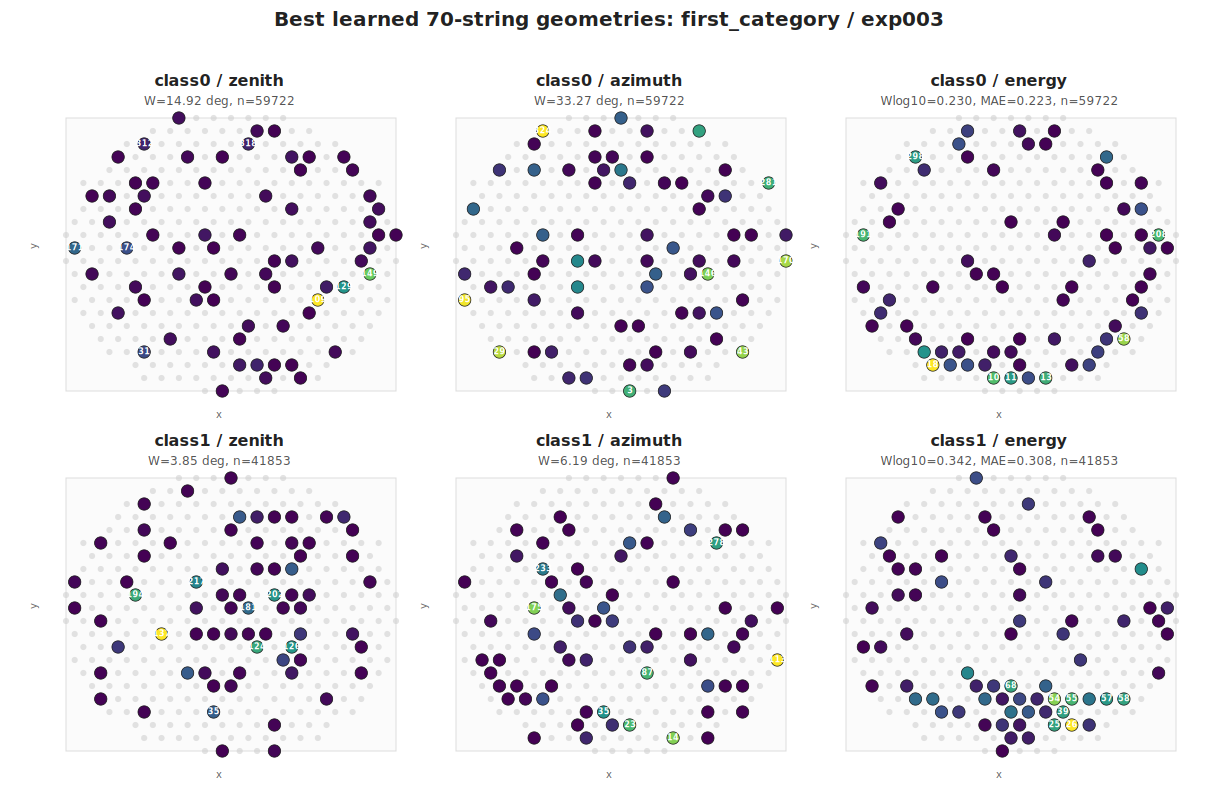

In [4]:
SELECTED_COLOR = '#1f77b4'
UNSELECTED_COLOR = '#d8d8d8'


def panel_svg(class_name, target, x0, y0, width, height, label_top_n=8):
    selection = read_selection(class_name, target)
    selected = [row for row in selection if row['selected_topk']]
    pad_l, pad_r, pad_t, pad_b = 42, 18, 52, 35
    plot_w = width - pad_l - pad_r
    plot_h = height - pad_t - pad_b
    xmin, xmax = EXTENT['xmin'], EXTENT['xmax']
    ymin, ymax = EXTENT['ymin'], EXTENT['ymax']

    def sx(x):
        return x0 + pad_l + (x - xmin) / (xmax - xmin) * plot_w

    def sy(y):
        return y0 + pad_t + (ymax - y) / (ymax - ymin) * plot_h

    parts = []
    parts.append(f"<rect x='{x0}' y='{y0}' width='{width}' height='{height}' fill='white'/>")
    parts.append(f"<rect x='{x0 + pad_l}' y='{y0 + pad_t}' width='{plot_w}' height='{plot_h}' fill='#fbfbfb' stroke='#dddddd'/>")

    for row in coords:
        parts.append(
            f"<circle cx='{sx(row['x']):.2f}' cy='{sy(row['y']):.2f}' r='3.1' fill='{UNSELECTED_COLOR}' opacity='0.62'/>"
        )

    for row in selected:
        parts.append(
            f"<circle cx='{sx(row['x']):.2f}' cy='{sy(row['y']):.2f}' r='6.2' fill='{SELECTED_COLOR}' stroke='#111111' stroke-width='0.7'/>"
        )

    for row in selected[:label_top_n]:
        parts.append(
            f"<text x='{sx(row['x']):.2f}' y='{sy(row['y']) + 2.3:.2f}' text-anchor='middle' font-size='8' font-weight='700' fill='white'>{row['string_id']}</text>"
        )

    title = html.escape(f'{class_name} / {target}')
    metric = html.escape(read_metric_label(class_name, target))
    parts.append(f"<text x='{x0 + width / 2:.1f}' y='{y0 + 20}' text-anchor='middle' font-size='16' font-weight='700' fill='#222222'>{title}</text>")
    parts.append(f"<text x='{x0 + width / 2:.1f}' y='{y0 + 39}' text-anchor='middle' font-size='12' fill='#555555'>{metric}</text>")
    parts.append(f"<circle cx='{x0 + pad_l + 10}' cy='{y0 + height - 13}' r='4.2' fill='{SELECTED_COLOR}' stroke='#111111' stroke-width='0.6'/>")
    parts.append(f"<text x='{x0 + pad_l + 20}' y='{y0 + height - 10}' font-size='10' fill='#555555'>selected top-70</text>")
    parts.append(f"<text x='{x0 + width / 2:.1f}' y='{y0 + height - 8}' text-anchor='middle' font-size='10' fill='#666666'>x</text>")
    parts.append(f"<text x='{x0 + 13}' y='{y0 + height / 2:.1f}' text-anchor='middle' font-size='10' fill='#666666' transform='rotate(-90 {x0 + 13} {y0 + height / 2:.1f})'>y</text>")
    return '\n'.join(parts)


def make_overview_svg():
    panel_w, panel_h = 390, 360
    margin = 24
    header_h = 42
    width = margin * 2 + panel_w * len(TARGETS)
    height = header_h + margin * 2 + panel_h * len(CLASSES)
    parts = [
        f"<svg xmlns='http://www.w3.org/2000/svg' width='{width}' height='{height}' viewBox='0 0 {width} {height}'>",
        "<rect width='100%' height='100%' fill='white'/>",
        f"<text x='{width / 2:.1f}' y='26' text-anchor='middle' font-size='20' font-weight='700' fill='#222222'>Best learned 70-string geometries: first_category / exp003</text>",
    ]
    for row_idx, class_name in enumerate(CLASSES):
        for col_idx, target in enumerate(TARGETS):
            x0 = margin + col_idx * panel_w
            y0 = header_h + margin + row_idx * panel_h
            parts.append(panel_svg(class_name, target, x0, y0, panel_w, panel_h))
    parts.append('</svg>')
    return '\n'.join(parts)


overview_svg = make_overview_svg()
overview_path = RESULTS_DIR / 'best_70_string_geometries_first_category_exp003.svg'
overview_path.write_text(overview_svg)
print(f'Saved overview: {overview_path}')
display(SVG(overview_svg))

In [5]:
# Optional: save one standalone SVG per class/target panel.
for class_name in CLASSES:
    for target in TARGETS:
        width, height = 430, 390
        svg = "\n".join([
            f"<svg xmlns='http://www.w3.org/2000/svg' width='{width}' height='{height}' viewBox='0 0 {width} {height}'>",
            panel_svg(class_name, target, 0, 0, width, height, label_top_n=10),
            '</svg>',
        ])
        out_path = RESULTS_DIR / f'best_70_strings_{class_name}_{target}.svg'
        out_path.write_text(svg)
        print(f'Saved: {out_path}')

Saved: /project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/full_geometry_emax1e6/geometry_selection/first_category/results/best_70_strings_class0_zenith.svg
Saved: /project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/full_geometry_emax1e6/geometry_selection/first_category/results/best_70_strings_class0_azimuth.svg
Saved: /project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/full_geometry_emax1e6/geometry_selection/first_category/results/best_70_strings_class0_energy.svg
Saved: /project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/full_geometry_emax1e6/geometry_selection/first_category/results/best_70_strings_class1_zenith.svg
Saved: /project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/full_geometry_emax1e6/geometry_selection/first_category/results/best_70_strings_class1_azimuth.svg
Saved: /project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/full_geometry_emax1e6/geometry_selection/first_category/results/best_7